In [1]:
# All imports
import plotly.express as px
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
df=pd.read_csv("cell_samples.csv")
print(df.index)
print("All columns are")
ai=0
for i in df:
    print(ai,i)
    ai+=1

RangeIndex(start=0, stop=699, step=1)
All columns are
0 Clump
1 UnifSize
2 UnifShape
3 MargAdh
4 SingEpiSize
5 BareNuc
6 BlandChrom
7 NormNucl
8 Mit
9 Class


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Clump        699 non-null    int64 
 1   UnifSize     699 non-null    int64 
 2   UnifShape    699 non-null    int64 
 3   MargAdh      699 non-null    int64 
 4   SingEpiSize  699 non-null    int64 
 5   BareNuc      699 non-null    object
 6   BlandChrom   699 non-null    int64 
 7   NormNucl     699 non-null    int64 
 8   Mit          699 non-null    int64 
 9   Class        699 non-null    int64 
dtypes: int64(9), object(1)
memory usage: 54.7+ KB


In [7]:
#Finding non integer value
for idx, value in enumerate(df['BareNuc']):
    try:
        int(value)
    except (ValueError, TypeError):
        print(f"Non-integer value at index {idx}: {value}")

Non-integer value at index 23: ?
Non-integer value at index 40: ?
Non-integer value at index 139: ?
Non-integer value at index 145: ?
Non-integer value at index 158: ?
Non-integer value at index 164: ?
Non-integer value at index 235: ?
Non-integer value at index 249: ?
Non-integer value at index 275: ?
Non-integer value at index 292: ?
Non-integer value at index 294: ?
Non-integer value at index 297: ?
Non-integer value at index 315: ?
Non-integer value at index 321: ?
Non-integer value at index 411: ?
Non-integer value at index 617: ?


In [8]:
# Lets replace all of them with the mode value 1
X = df
X['BareNuc'] = X['BareNuc'].replace('?', 1)
X['BareNuc'] = X['BareNuc'].astype(int)
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Clump        699 non-null    int64
 1   UnifSize     699 non-null    int64
 2   UnifShape    699 non-null    int64
 3   MargAdh      699 non-null    int64
 4   SingEpiSize  699 non-null    int64
 5   BareNuc      699 non-null    int64
 6   BlandChrom   699 non-null    int64
 7   NormNucl     699 non-null    int64
 8   Mit          699 non-null    int64
 9   Class        699 non-null    int64
dtypes: int64(10)
memory usage: 54.7 KB


In [18]:
# Drop class for unsupervised learning
X = df.drop('Class', axis=1)
print(X.columns)

Index(['Clump', 'UnifSize', 'UnifShape', 'MargAdh', 'SingEpiSize', 'BareNuc',
       'BlandChrom', 'NormNucl', 'Mit'],
      dtype='object')


In [19]:
scaler = StandardScaler()
Xscaled = scaler.fit_transform(X)
print(Xscaled)

[[ 0.20693572 -0.69999505 -0.74329904 ... -0.17966213 -0.61182504
  -0.34391178]
 [ 0.20693572  0.28384518  0.2668747  ... -0.17966213 -0.28411186
  -0.34391178]
 [-0.50386559 -0.69999505 -0.74329904 ... -0.17966213 -0.61182504
  -0.34391178]
 ...
 [ 0.20693572  2.25152563  2.28722218 ...  1.87236122  2.33759359
   0.23956962]
 [-0.14846494  1.59563215  0.94032386 ...  2.69317056  1.02674087
  -0.34391178]
 [-0.14846494  1.59563215  1.61377302 ...  2.69317056  0.37131451
  -0.34391178]]


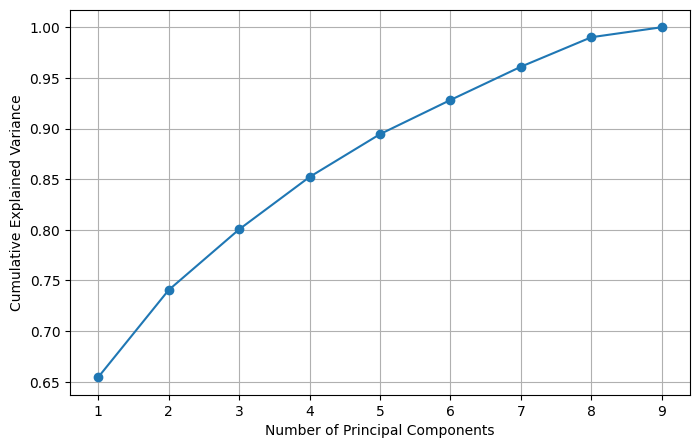

In [20]:
pca = PCA()
pca.fit(Xscaled)

cumulativevariance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulativevariance)+1),cumulativevariance,marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid()
plt.show()

In [21]:
# 7 is the best number 
ncomponents = np.argmax(cumulativevariance >= 0.95) + 1
print("Best number of components:", ncomponents)

Best number of components: 7


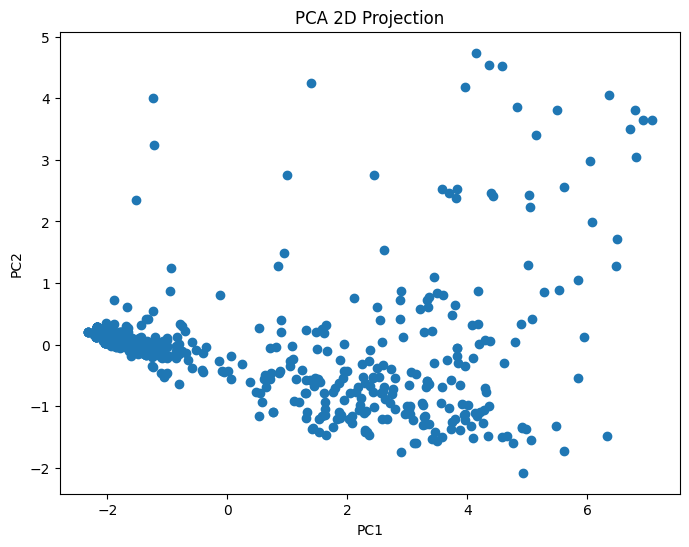

In [22]:
# 2d PCA Visualization
pca2d = PCA(n_components=2)
Xpca2d = pca2d.fit_transform(Xscaled)

plt.figure(figsize=(8,6))
plt.scatter(Xpca2d[:,0], Xpca2d[:,1])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA 2D Projection')
plt.show()

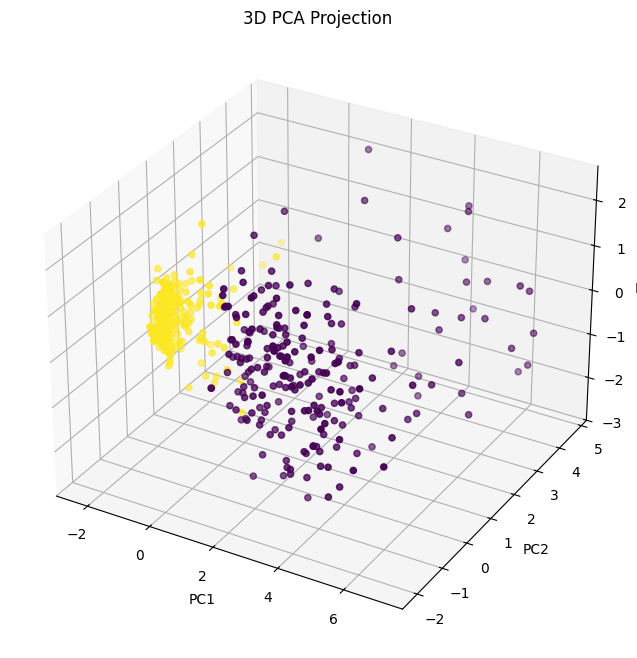

In [24]:
from mpl_toolkits.mplot3d import Axes3D

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_pca_3d[:,0],
    X_pca_3d[:,1],
    X_pca_3d[:,2],
    c=clusters
)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D PCA Projection')
plt.show()

In [26]:
plt.savefig('PCA3d.png',dpi=300,bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [27]:
# Variance by each number set
for i, var in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"PC{i}: {var:.4f}")

PC1: 0.6545
PC2: 0.0861
PC3: 0.0599
PC4: 0.0517
PC5: 0.0423
PC6: 0.0337
PC7: 0.0329
PC8: 0.0291
PC9: 0.0099
